# Week 3 Clustering Notebook

This notebook explores the synthetic clustering dataset using k-means and hierarchical clustering.

The goal is to understand how feature selection, scaling and the number of clusters affect the clustering result.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv("synthetic-clustering-dataset.csv")

df.head()

,student_key,course_week,group_code,quiz_completed,quiz_score_pct,task_submitted,submission_delay_minutes,task_attempts,monday_activity_count,recorded_attendance,concept_map_submitted,concept_coverage_pct,artifact_size_kb,previous_task_score_pct
0,SYN001,1,G07,1,98.3,1,6.0,3,29,1,0,NaN,1126.4,75.1
1,SYN001,2,G07,1,94.6,1,7.2,4,36,1,1,81.8,875.0,66.0
2,SYN001,3,G07,1,85.4,1,-11.8,5,35,1,1,90.5,775.5,87.9
3,SYN002,1,G03,1,66.8,1,-27.4,1,24,1,1,57.2,210.3,77.2
4,SYN002,2,G03,1,69.0,0,NaN,0,36,1,1,52.8,190.7,65.0


1. Understand the data

In [3]:
# Size of the dataset
print("Dataset shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (120, 14)

Columns:
['student_key', 'course_week', 'group_code', 'quiz_completed', 'quiz_score_pct', 'task_submitted', 'submission_delay_minutes', 'task_attempts', 'monday_activity_count', 'recorded_attendance', 'concept_map_submitted', 'concept_coverage_pct', 'artifact_size_kb', 'previous_task_score_pct']


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   student_key               120 non-null    str    
 1   course_week               120 non-null    int64  
 2   group_code                120 non-null    str    
 3   quiz_completed            120 non-null    int64  
 4   quiz_score_pct            92 non-null     float64
 5   task_submitted            120 non-null    int64  
 6   submission_delay_minutes  114 non-null    float64
 7   task_attempts             120 non-null    int64  
 8   monday_activity_count     120 non-null    int64  
 9   recorded_attendance       120 non-null    int64  
 10  concept_map_submitted     120 non-null    int64  
 11  concept_coverage_pct      103 non-null    float64
 12  artifact_size_kb          120 non-null    float64
 13  previous_task_score_pct   115 non-null    float64
dtypes: float64(5), int64(

In [5]:
# Missing values in each column
df.isnull().sum()

student_key                  0
course_week                  0
group_code                   0
quiz_completed               0
quiz_score_pct              28
task_submitted               0
submission_delay_minutes     6
task_attempts                0
monday_activity_count        0
recorded_attendance          0
concept_map_submitted        0
concept_coverage_pct        17
artifact_size_kb             0
previous_task_score_pct      5
dtype: int64

In [6]:
# Summary of numerical variables
df.describe().T

,count,mean,std,min,25%,50%,75%,max
course_week,120.0,2.000000,0.819920,1.0,1.000,2.00,3.000,3.0
quiz_completed,120.0,0.766667,0.424726,0.0,1.000,1.00,1.000,1.0
quiz_score_pct,92.0,72.128261,17.539872,28.9,61.275,73.35,85.475,100.0
task_submitted,120.0,0.950000,0.218859,0.0,1.000,1.00,1.000,1.0
submission_delay_minutes,114.0,31.785965,60.077758,-90.0,-6.800,31.05,75.575,166.2
task_attempts,120.0,2.041667,1.368283,0.0,1.000,2.00,3.000,6.0
monday_activity_count,120.0,25.058333,8.091178,2.0,20.000,27.00,31.000,40.0
recorded_attendance,120.0,0.950000,0.218859,0.0,1.000,1.00,1.000,1.0
concept_map_submitted,120.0,0.858333,0.350170,0.0,1.000,1.00,1.000,1.0
concept_coverage_pct,103.0,66.993204,16.859856,26.5,55.100,66.80,79.100,100.0


## 1. Understand the Data

**What does one observation represent?**

One observation represents one student in one course week. There are 40 synthetic students and each student has records for three weeks, giving 120 observations.

**Which variables could meaningfully describe similarity?**

I chose quiz score, submission delay, task attempts, Monday activity count, concept coverage, artifact size and previous task score. These variables describe differences in performance, activity and task behaviour.

**Which variables should not be used as clustering features?**

`student_key` is only an identifier, so it should not be used. `group_code` is also a group identifier and the codes do not represent numerical distance. I also left out `course_week` because I do not want the clusters to be mainly based on whether the observation came from week 1, 2 or 3.

**Are there identifiers?**

Yes. `student_key` identifies the student and `group_code` identifies the group.

**Are there missing values?**

Yes. Some columns have missing values. For example, quiz score is missing when a quiz was not completed, and concept coverage can be missing when a concept map was not submitted.

**Are the numerical scales very different?**

Yes. Some variables are percentages, task attempts are small numbers, while artifact size can be hundreds or thousands of KB. This matters because k-means uses distance, so larger-scale variables could have too much influence without scaling.

2. Prepare the features

## 2. Prepare the Features

I selected seven numerical features that describe performance, activity and task behaviour:

- quiz score
- submission delay
- task attempts
- Monday activity count
- concept coverage
- artifact size
- previous task score

I excluded identifiers such as student key and group code.

Some selected features contain missing values, so I used median imputation. After that, I standardized the features because their numerical scales are very different.

In [7]:
features = [
    "quiz_score_pct",
    "submission_delay_minutes",
    "task_attempts",
    "monday_activity_count",
    "concept_coverage_pct",
    "artifact_size_kb",
    "previous_task_score_pct"
]

X = df[features].copy()

X.head()

,quiz_score_pct,submission_delay_minutes,task_attempts,monday_activity_count,concept_coverage_pct,artifact_size_kb,previous_task_score_pct
0,98.3,6.0,3,29,NaN,1126.4,75.1
1,94.6,7.2,4,36,81.8,875.0,66.0
2,85.4,-11.8,5,35,90.5,775.5,87.9
3,66.8,-27.4,1,24,57.2,210.3,77.2
4,69.0,NaN,0,36,52.8,190.7,65.0


In [8]:
X.isnull().sum()

quiz_score_pct              28
submission_delay_minutes     6
task_attempts                0
monday_activity_count        0
concept_coverage_pct        17
artifact_size_kb             0
previous_task_score_pct      5
dtype: int64

In [9]:
imputer = SimpleImputer(strategy="median")

X_imputed = imputer.fit_transform(X)

X_imputed = pd.DataFrame(
    X_imputed,
    columns=features,
    index=df.index
)

X_imputed.isnull().sum()

quiz_score_pct              0
submission_delay_minutes    0
task_attempts               0
monday_activity_count       0
concept_coverage_pct        0
artifact_size_kb            0
previous_task_score_pct     0
dtype: int64

In [10]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_imputed)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=features,
    index=df.index
)

X_scaled.head()

,quiz_score_pct,submission_delay_minutes,task_attempts,monday_activity_count,concept_coverage_pct,artifact_size_kb,previous_task_score_pct
0,1.693836,-0.441671,0.703328,0.489199,-0.010669,1.892011,0.578287
1,1.451734,-0.421088,1.437235,1.357966,0.954324,1.134798,-0.027982
2,0.849753,-0.746992,2.171142,1.233856,1.514019,0.835105,1.431060
3,-0.367296,-1.014576,-0.764487,-0.131349,-0.628264,-0.867268,0.718195
4,-0.223344,-0.011993,-1.498394,1.357966,-0.911328,-0.926303,-0.094605


In [11]:
X_scaled.describe().T[["mean", "std"]]

,mean,std
quiz_score_pct,-1.509903e-15,1.004193
submission_delay_minutes,2.960595e-17,1.004193
task_attempts,1.036208e-16,1.004193
monday_activity_count,-5.921189e-17,1.004193
concept_coverage_pct,-2.072416e-16,1.004193
artifact_size_kb,-6.661338e-17,1.004193
previous_task_score_pct,-1.036208e-16,1.004193


## 3. Run K-Means

I started with 3 clusters. The cluster numbers 0, 1 and 2 are only labels. They do not mean that one cluster is better or worse than another.

In [12]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)

df["cluster"] = cluster_labels

In [13]:
df[["student_key", "course_week", "cluster"]].head(15)

,student_key,course_week,cluster
0,SYN001,1,2
1,SYN001,2,2
2,SYN001,3,2
3,SYN002,1,1
4,SYN002,2,1
5,SYN002,3,2
6,SYN003,1,1
7,SYN003,2,1
8,SYN003,3,1
9,SYN004,1,0


In [14]:
df["cluster"].value_counts().sort_index()

cluster
0    38
1    45
2    37
Name: count, dtype: int64

centers_original = scaler.inverse_transform(kmeans.cluster_centers_)

centers_df = pd.DataFrame(
    centers_original,
    columns=features
)

centers_df

## 4. Describe the Clusters

I compared the clusters using the original variables rather than only looking at the standardized values.

In [15]:
cluster_summary = df.groupby("cluster").agg(
    size=("student_key", "size"),
    mean_quiz_score=("quiz_score_pct", "mean"),
    mean_attempts=("task_attempts", "mean"),
    mean_activity=("monday_activity_count", "mean"),
    mean_submission_delay=("submission_delay_minutes", "mean"),
    mean_concept_coverage=("concept_coverage_pct", "mean"),
    mean_artifact_size=("artifact_size_kb", "mean"),
    mean_previous_score=("previous_task_score_pct", "mean")
).round(2)

cluster_summary

,size,mean_quiz_score,mean_attempts,mean_activity,mean_submission_delay,mean_concept_coverage,mean_artifact_size,mean_previous_score
cluster,,,,,,,,
0,38,50.98,2.05,18.00,73.15,52.69,419.27,51.84
1,45,82.69,1.18,26.58,-18.25,78.62,420.83,78.17
2,37,76.51,3.08,30.46,46.99,65.07,673.49,67.12


### Cluster description

The three clusters have measurable differences in quiz score, activity, submission delay and the other selected features.

I did not label the clusters as "good", "bad" or "motivated" students because the clustering only shows differences in the measured variables.

Some variables show clearer differences between the clusters than others. The cluster labels themselves have no ranking.

## 5. Visualization

I plotted quiz score against Monday activity count and coloured the observations by their k-means cluster.

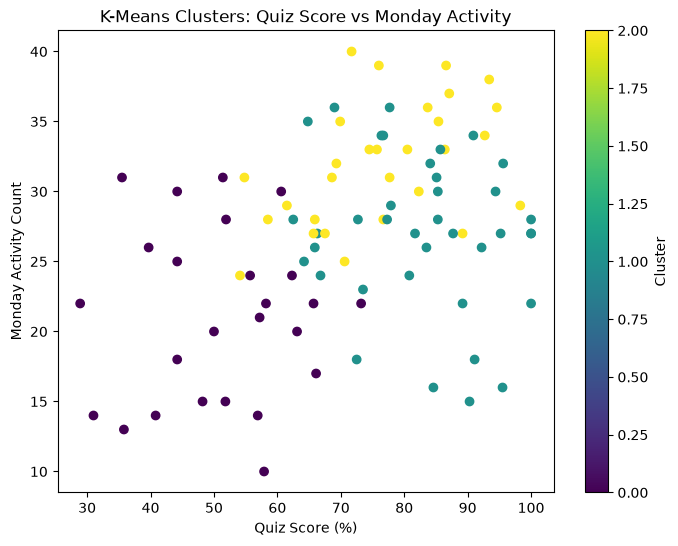

In [16]:
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    df["quiz_score_pct"],
    df["monday_activity_count"],
    c=df["cluster"]
)

plt.xlabel("Quiz Score (%)")
plt.ylabel("Monday Activity Count")
plt.title("K-Means Clusters: Quiz Score vs Monday Activity")

plt.colorbar(scatter, label="Cluster")
plt.show()

The visualization shows how the clusters appear when looking at two variables. There is some separation, but the clusters are based on all seven selected features, not only these two variables.

## 6. Compare Different Numbers of Clusters

I tested k values from 2 to 6. I used the silhouette score as one way to compare how well separated the clusters are.

In [17]:
results = []

for k in range(2, 7):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = model.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    
    sizes = pd.Series(labels).value_counts().sort_index().to_dict()
    
    results.append({
        "k": k,
        "silhouette_score": round(score, 3),
        "cluster_sizes": sizes
    })

results_df = pd.DataFrame(results)

results_df

,k,silhouette_score,cluster_sizes
0,2,0.210,"{0: 61, 1: 59}"
1,3,0.189,"{0: 38, 1: 45, 2: 37}"
2,4,0.164,"{0: 24, 1: 35, 2: 26, 3: 35}"
3,5,0.158,"{0: 31, 1: 35, 2: 18, 3: 19, 4: 17}"
4,6,0.152,"{0: 23, 1: 21, 2: 19, 3: 23, 4: 21, 5: 13}"


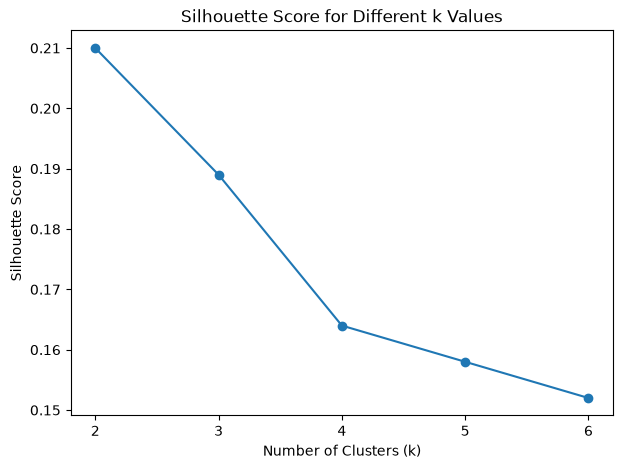

In [18]:
plt.figure(figsize=(7, 5))

plt.plot(
    results_df["k"],
    results_df["silhouette_score"],
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different k Values")
plt.xticks(range(2, 7))

plt.show()

The silhouette scores changed when I changed the number of clusters. A higher silhouette score suggests clearer separation, but I would not choose the number of clusters based only on this value. The cluster sizes and whether the groups are meaningful also need to be considered.

## 7. Test the Effect of Scaling

I compared k-means with and without standardization using the same imputed features and k=3.

In [19]:
kmeans_unscaled = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels_unscaled = kmeans_unscaled.fit_predict(X_imputed)

In [20]:
labels_scaled = cluster_labels

In [21]:
scaling_comparison = pd.DataFrame({
    "scaled_cluster": labels_scaled,
    "unscaled_cluster": labels_unscaled
})

pd.crosstab(
    scaling_comparison["scaled_cluster"],
    scaling_comparison["unscaled_cluster"]
)

unscaled_cluster,0,1,2
scaled_cluster,,,
0,28,0,10
1,32,0,13
2,17,3,17


In [22]:
scaling_comparison = pd.DataFrame({
    "scaled_cluster": labels_scaled,
    "unscaled_cluster": labels_unscaled
})

pd.crosstab(
    scaling_comparison["scaled_cluster"],
    scaling_comparison["unscaled_cluster"]
)

unscaled_cluster,0,1,2
scaled_cluster,,,
0,28,0,10
1,32,0,13
2,17,3,17


In [24]:
scaled_silhouette = silhouette_score(X_scaled, labels_scaled)
unscaled_silhouette = silhouette_score(X_imputed, labels_unscaled)

print("Scaled silhouette:", round(scaled_silhouette, 3))
print("Unscaled silhouette:", round(unscaled_silhouette, 3))

Scaled silhouette: 0.189
Unscaled silhouette: 0.589


In [25]:
X_imputed.agg(["min", "max"]).T

,min,max
quiz_score_pct,28.9,100.0
submission_delay_minutes,-90.0,166.2
task_attempts,0.0,6.0
monday_activity_count,2.0,40.0
concept_coverage_pct,26.5,100.0
artifact_size_kb,103.5,2257.7
previous_task_score_pct,32.2,100.0


Scaling affected the clustering because the selected variables have very different numerical ranges. Without scaling, a variable such as artifact size can have much more influence on Euclidean distance than variables with smaller ranges.

After standardization, each selected feature is placed on a comparable scale. This gives the other variables a more balanced influence on the clustering.

## 8. Compare with Hierarchical Clustering

I used Agglomerative Clustering with the same scaled features and three clusters. I then compared its cluster assignments with k-means.

In [26]:
hierarchical = AgglomerativeClustering(n_clusters=3)

hierarchical_labels = hierarchical.fit_predict(X_scaled)

df["hierarchical_cluster"] = hierarchical_labels

In [27]:
df["hierarchical_cluster"].value_counts().sort_index()

hierarchical_cluster
0    76
1    32
2    12
Name: count, dtype: int64

In [28]:
pd.crosstab(
    df["cluster"],
    df["hierarchical_cluster"],
    rownames=["K-Means"],
    colnames=["Hierarchical"]
)

Hierarchical,0,1,2
K-Means,,,
0,38,0,0
1,12,32,1
2,26,0,11


In [29]:
hierarchical_silhouette = silhouette_score(
    X_scaled,
    hierarchical_labels
)

print(
    "Hierarchical silhouette:",
    round(hierarchical_silhouette, 3)
)

Hierarchical silhouette: 0.18


K-means and hierarchical clustering produced similar groups for some observations, while some observations were assigned differently.

This is reasonable because the two algorithms build clusters in different ways. The comparison also shows that the clustering result depends partly on the algorithm used, so the clusters should not be treated as absolute groups.

## 9. Interpretation and Limitations

### Which clustering solution seems most useful?

I compared the solutions using silhouette score, cluster sizes and how understandable the measured differences between the clusters were. I would not select a solution based only on the highest silhouette score.

### Why?

A useful clustering solution should have reasonably separated groups but should also produce groups that can be interpreted using the original variables.

### Are the clusters clearly separated?

The clusters show some differences, but they should not be treated as perfectly separated natural groups. The result depends on the selected features, preprocessing and algorithm.

### Would another reasonable feature selection change the result?

Yes. Clustering is based on similarity in the selected features. Removing or adding a feature could change the distances between observations and therefore change cluster membership.

### Could another algorithm produce different groups?

Yes. The comparison with hierarchical clustering shows that another clustering method can group some observations differently.

### What can I safely conclude from the clusters?

I can describe measured differences between the groups in the variables used for clustering, such as quiz score, activity, attempts or submission delay.

### What should I avoid concluding?

I should not use the clusters to label students as "good", "bad", "weak" or "motivated". The clusters only describe patterns in this synthetic dataset and do not explain why those patterns occurred.